# Phase 1 — Data exploration (local only)

This notebook is meant to run on your laptop: it **does not** use NERSC, CFS, or SCRATCH.

**Kernel:** select the project interpreter **`.venv/bin/python`** at the repo root (create it with `bash scripts/bootstrap_venv.sh` from the repo root if needed). The first code cell detects the repo whether your Jupyter cwd is the repo root or `notebooks/`.

1. **Downloads** one real DR1 iron healpix tile by default (two files: `coadd` + `redrock`) from the DESI public portal ([DESI public data](https://data.desi.lbl.gov/public/), DR1 under `dr1/`). Tiles are chosen in the **same survey/program order** as NERSC `build_dr1_index.py` / `dr1_1k_scratch.jsonl` (first tile available on the portal; `sv3` is skipped if absent). Increase `N_HEALPIX` for more tiles (more disk).
2. Writes `data/manifests/train_eval_dr1.jsonl` and stores FITS under `data/dr1_public/` (gitignored).
3. Plots several stitched spectra (**up to 5**) with **emission** (red) and **absorption** (blue) lines at observed wavelength.
4. Walks through **cleaning / preprocessing** for Phase 5 (`stitch_bands`, quality cuts, collate, **AION grid** resample to 8704).

Re-run the download cell after deleting `data/dr1_public/` if you want a fresh copy.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

_cwd = Path.cwd().resolve()
if (_cwd / "src" / "desifm").is_dir():
    REPO = _cwd
elif (_cwd.parent / "src" / "desifm").is_dir():
    REPO = _cwd.parent
else:
    raise FileNotFoundError(
        f"Could not find repo root (expected src/desifm). cwd={_cwd}"
    )
sys.path.insert(0, str(REPO / "src"))

from desifm.constants import GRID_SIZE
from desifm.data.dr1_stream import DR1StreamDataset, load_manifest
from desifm.tokenization.aion_grid import resample_spectrum_batch
from desifm.viz.spectrum_plot import REST_LINES, load_stitched_spectrum, plot_spectrum_with_lines

try:
    from IPython import get_ipython

    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

plt.rcParams["figure.figsize"] = (12, 4)

DATA_ROOT = REPO / "data" / "dr1_public"
MANIFEST_PATH = REPO / "data" / "manifests" / "train_eval_dr1.jsonl"
N_HEALPIX = 1  # minimal: one healpix = coadd + redrock (~hundreds of MB). Set to 2+ for more tiles.

print("Data directory:", DATA_ROOT)
print("Manifest:", MANIFEST_PATH)
print("AION grid size:", GRID_SIZE)

Data directory: /Users/jonathansamuel/projects/cs-686-dl/final-project/data/dr1_public
Manifest: /Users/jonathansamuel/projects/cs-686-dl/final-project/data/manifests/train_eval_dr1.jsonl
AION grid size: 8704


## 1. Download healpix tile(s) (public DR1, training walk order)

Fetches `coadd-*.fits` and `redrock-*.fits` from `https://data.desi.lbl.gov/public/dr1/` into `data/dr1_public/`, preserving the DR1 path layout. **Default: one tile** (~hundreds of MB). Discovery follows NERSC manifest order (`sv3`→`main`, `bright`→`dark`); skips surveys not on the portal.

CLI equivalent: `python scripts/download_dr1_local.py --training-order` (add `--max-tiles 2` for more).

In [2]:
from desifm.data.public_dr1 import discover_public_training_tiles, ensure_dr1_tiles_local

tiles = discover_public_training_tiles(N_HEALPIX)
print("tiles (training walk order, public portal):", tiles)
ensure_dr1_tiles_local(DATA_ROOT, MANIFEST_PATH, tiles)
records = load_manifest(MANIFEST_PATH)

print(f"{len(records)} healpix tiles (local FITS)")
for r in records:
    print(f"  healpix {r['healpix']} ({r['survey']}/{r['program']}) n_rows={r.get('n_rows')}")

tiles (training walk order, public portal): [('main', 'bright', '0', 0)]
skip (exists): /Users/jonathansamuel/projects/cs-686-dl/final-project/data/dr1_public/spectro/redux/iron/healpix/main/bright/0/0/coadd-main-bright-0.fits
skip (exists): /Users/jonathansamuel/projects/cs-686-dl/final-project/data/dr1_public/spectro/redux/iron/healpix/main/bright/0/0/redrock-main-bright-0.fits
1 healpix tiles (local FITS)
  healpix 0 (main/bright) n_rows=684


## 2. Optional: reload manifest

Skip if you ran the download cell already (`records` is set there).

In [3]:
records = load_manifest(MANIFEST_PATH)
assert records, "Run section 1 to download FITS and create the manifest."

## 3. Pick several good spectra

Same filters as `DR1StreamDataset`: `ZWARN==0`, `COADD_FIBERSTATUS==0`, nonzero flux. We collect up to **5** examples (first is reused in the preprocessing section below).

In [4]:
N_GOOD_EXAMPLES = 5

def find_good_examples(records, n=5, max_tries_per_tile=400):
    """Up to n spectra passing DR1StreamDataset-style cuts; z > 0.01."""
    out = []
    seen = set()
    for rec in records:
        if len(out) >= n:
            break
        coadd_path, redrock_path = rec["coadd"], rec["redrock"]
        n_rows = rec.get("n_rows")
        if n_rows is None:
            from astropy.io import fits

            with fits.open(coadd_path, memmap=True) as h:
                n_rows = int(h["FIBERMAP"].header["NAXIS2"])
        for row in range(min(n_rows, max_tries_per_tile)):
            if len(out) >= n:
                break
            key = (str(coadd_path), int(row))
            if key in seen:
                continue
            spec = load_stitched_spectrum(coadd_path, redrock_path, row, require_good_z=True)
            if spec is not None and spec["z"] > 0.01:
                spec["row"] = row
                spec["coadd"] = coadd_path
                spec["healpix"] = rec["healpix"]
                seen.add(key)
                out.append(spec)
    if not out:
        raise RuntimeError("No good spectrum found in manifest")
    return out


specs = find_good_examples(records, n=N_GOOD_EXAMPLES)
spec = specs[0]
print(f"Found {len(specs)} example(s)")
for i, sp in enumerate(specs):
    print(
        f"  [{i}] healpix={sp['healpix']} row={sp['row']} z={sp['z']:.4f} "
        f"zwarn={sp['zwarn']} fiberstatus={sp['fiberstatus']} "
        f"pixels={len(sp['flux'])}"
    )

Found 5 example(s)
  [0] healpix=0 row=0 z=0.3640 zwarn=0 fiberstatus=0 pixels=7781
  [1] healpix=0 row=1 z=0.3937 zwarn=0 fiberstatus=0 pixels=7781
  [2] healpix=0 row=2 z=0.2856 zwarn=0 fiberstatus=0 pixels=7781
  [3] healpix=0 row=3 z=0.1636 zwarn=0 fiberstatus=0 pixels=7781
  [4] healpix=0 row=4 z=0.2679 zwarn=0 fiberstatus=0 pixels=7781


## 4. Stitched spectra + emission / absorption lines

One panel per example. Rest-frame lines are shifted to observed wavelength λ_obs = λ_rest × (1 + z). Red dashed = emission; navy = absorption. Line list printed for the **first** example.

**Why flux can look “stuck at zero”:** DESI coadd flux is numerically **small** (often ~10⁻¹⁷ erg/s/cm²/Å in native FITS units), so default y-ticks may read **0.00** everywhere unless scientific notation is used. Also, **±1σ** from `ivar` uses σ = 1/√ivar; a few very **low-ivar** pixels have enormous σ and used to stretch the y-axis so the real spectrum looked flat—`plot_spectrum_with_lines` now **caps** that band for display only (training still uses full `ivar`) and sets **adaptive y-limits** from good-pixel flux (median ± a few σ) so the continuum is visible.

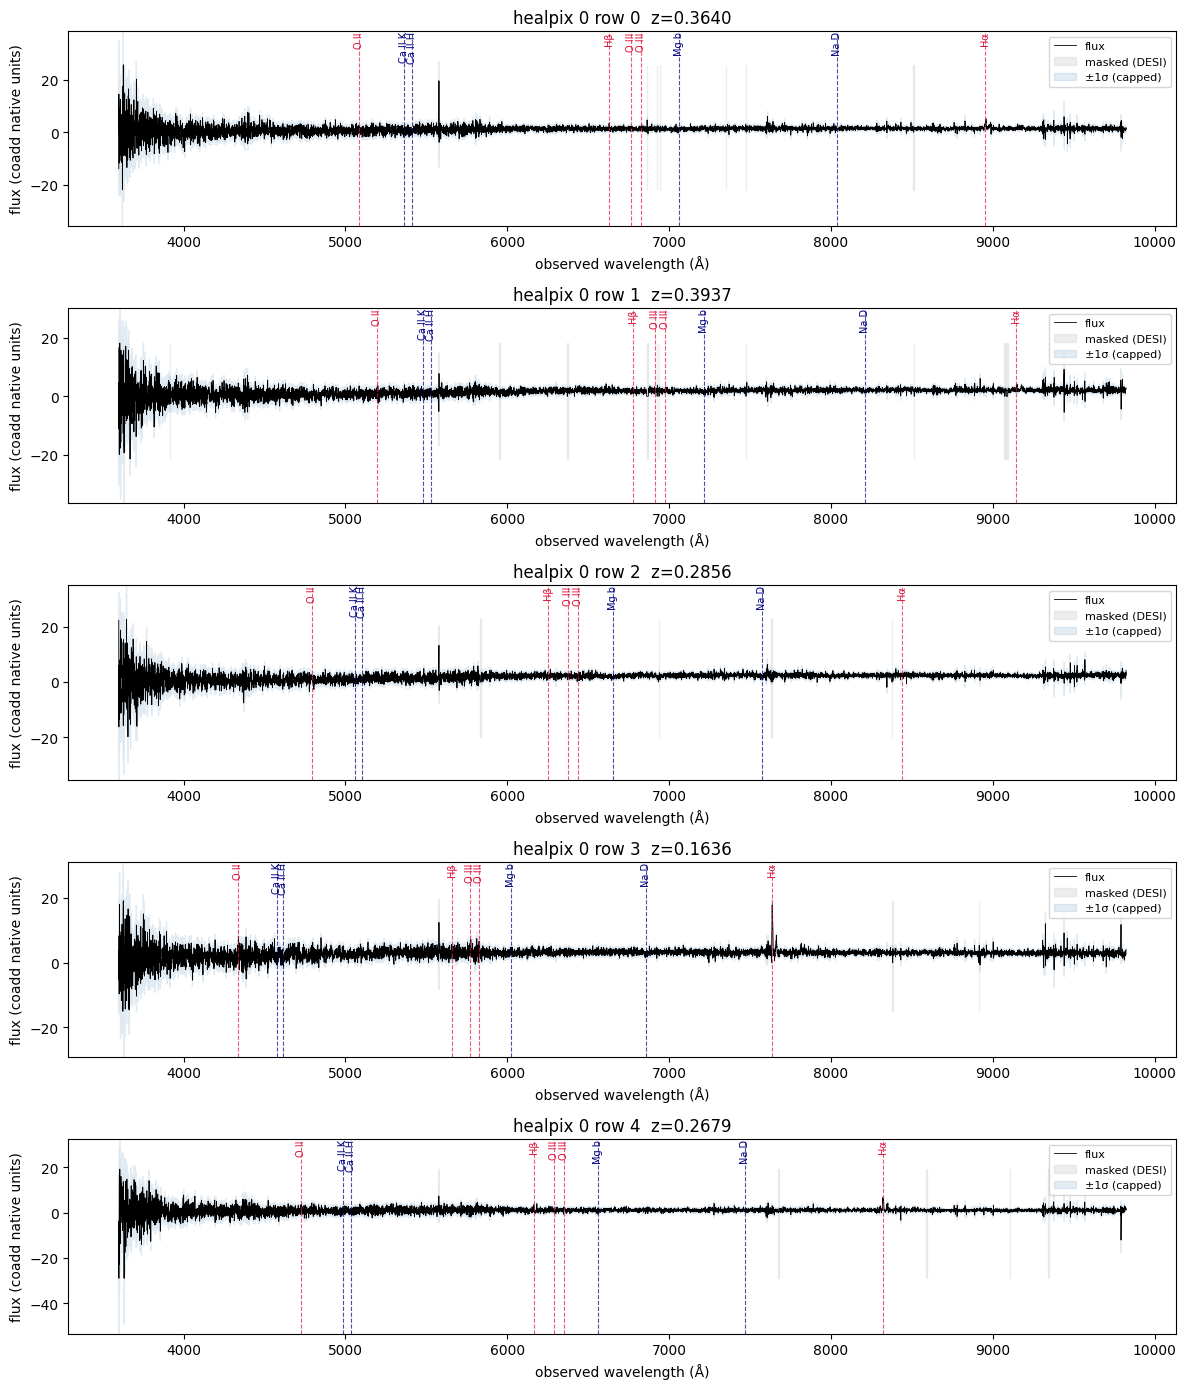

Line list (rest Å → observed @ z) for first example:
  Lyα        1215.7 →   1658.1  (abs)
  O II       3727.7 →   5084.5  (emi)
  Ca II K    3933.7 →   5365.4  (abs)
  Ca II H    3968.6 →   5413.0  (abs)
  Hβ         4861.4 →   6630.7  (emi)
  O III      4958.9 →   6763.8  (emi)
  O III      5006.8 →   6829.2  (emi)
  Mg b       5175.5 →   7059.3  (abs)
  Na D       5892.9 →   8037.8  (abs)
  Hα         6562.9 →   8951.5  (emi)


In [5]:
n_show = len(specs)
fig, axes = plt.subplots(n_show, 1, figsize=(12, 2.8 * n_show), sharex=False)
if n_show == 1:
    axes = [axes]
for ax, sp in zip(axes, specs):
    plot_spectrum_with_lines(
        ax,
        sp["wavelength"],
        sp["flux"],
        sp["z"],
        mask=sp["mask"],
        ivar=sp["ivar"],
        title=f"healpix {sp['healpix']} row {sp['row']}  z={sp['z']:.4f}",
    )
plt.tight_layout()
plt.show()

print("Line list (rest Å → observed @ z) for first example:")
for w_rest, label, kind in REST_LINES:
    w_obs = w_rest * (1 + spec["z"])
    print(f"  {label:8s} {w_rest:8.1f} → {w_obs:8.1f}  ({kind})")

## 5. Cleaning & preprocessing pipeline (Phase 5 / AION)

| Step | Where | What |
|------|-------|------|
| Band stitch | `stitch_bands` | B/R/Z → one wavelength, flux, ivar, mask |
| Quality cuts | `DR1StreamDataset` | `ZWARN==0`, good fiber status, non-zero flux |
| Batch pad | `collate_spectra` | Pad variable length to max in batch |
| AION grid | `resample_spectrum_batch` | Linear resample flux/ivar/wave; nearest mask → **8704** |
| Tokenize | `AionSpectrumTokenizer` | Frozen HF codec → **273** codes per spectrum |

Legacy in-repo `SpectrumCodec` (arcsinh + trainable LFQ) is **not** used in Phase 5.


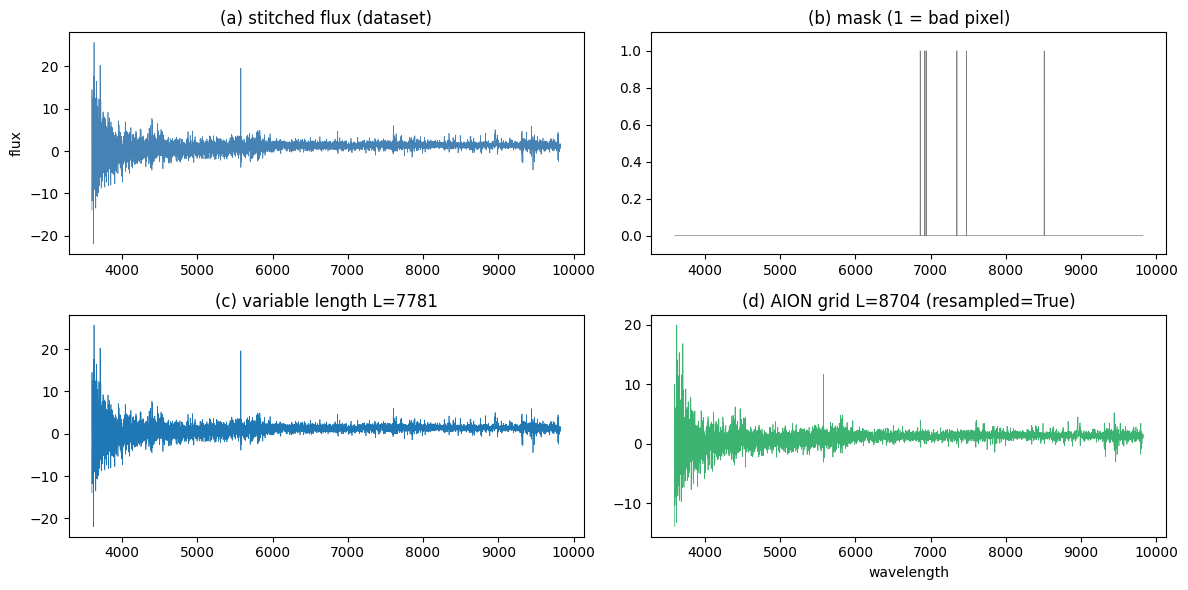

In [6]:
from astropy.io import fits

row = spec["row"]
with fits.open(spec["coadd"], memmap=True) as coadd:
    flux_b = coadd["B_FLUX"].data[row]
    wave_b = coadd["B_WAVELENGTH"].data

flux_t = torch.as_tensor(spec["flux"], dtype=torch.float32).unsqueeze(0)
ivar_t = torch.as_tensor(spec["ivar"], dtype=torch.float32).unsqueeze(0)
mask_t = torch.as_tensor(spec["mask"], dtype=torch.bool).unsqueeze(0)
wave_t = torch.as_tensor(spec["wavelength"], dtype=torch.float32).unsqueeze(0)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# (a) raw stitched
ax = axes[0, 0]
ax.plot(spec["wavelength"], spec["flux"], lw=0.5, color="steelblue")
ax.set_title("(a) stitched flux (dataset)")
ax.set_ylabel("flux")

# (b) good-pixel mask
ax = axes[0, 1]
ax.plot(spec["wavelength"], spec["mask"].astype(float), lw=0.5, color="gray")
ax.set_title("(b) mask (1 = bad pixel)")
ax.set_ylim(-0.1, 1.1)

# (c) padded batch slice (one spectrum)
ax = axes[1, 0]
ax.plot(spec["wavelength"], spec["flux"], lw=0.5)
ax.set_title(f"(c) variable length L={len(spec['flux'])}")

# (d) AION grid resample
flux_g, _, mask_g, wave_g, did = resample_spectrum_batch(
    flux_t, ivar_t, mask_t, wave_t, length=GRID_SIZE
)
ax = axes[1, 1]
ax.plot(wave_g[0].numpy(), flux_g[0].numpy(), lw=0.5, color="mediumseagreen")
ax.set_title(f"(d) AION grid L={GRID_SIZE} (resampled={did})")
ax.set_xlabel("wavelength")

plt.tight_layout()
plt.show()


## 6. Compare with `DR1StreamDataset` batch

Training collates variable-length spectra, then `AionSpectrumTokenizer` resamples each row to 8704 before encoding.


In [7]:
from desifm.data.dr1_stream import collate_spectra

ds = DR1StreamDataset(records, max_spectra=20)
items = [ds[i] for i in range(len(ds)) if ds[i] is not None]
batch = collate_spectra(items)
print("collated flux shape:", tuple(batch["flux"].shape))
print("collated wavelength shape:", tuple(batch["wavelength"].shape))

flux_g, ivar_g, mask_g, wave_g, did = resample_spectrum_batch(
    batch["flux"], batch["ivar"], batch["mask"], batch["wavelength"], length=GRID_SIZE
)
print("AION grid shape:", tuple(flux_g.shape))


collated flux shape: (18, 7781)
collated wavelength shape: (18, 7781)
AION grid shape: (18, 8704)
